# Customer Churn Analysis

In this project, I analyzed customer churn data using Python to identify patterns that lead customers to leave a service. The goal was to explore customer behavior and provide insights that can help improve retention.

This project focuses on data cleaning, visualization, and turning data into business insights.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
df = df.dropna()

In [8]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [9]:
churn_rate = df['Churn'].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 26.58%


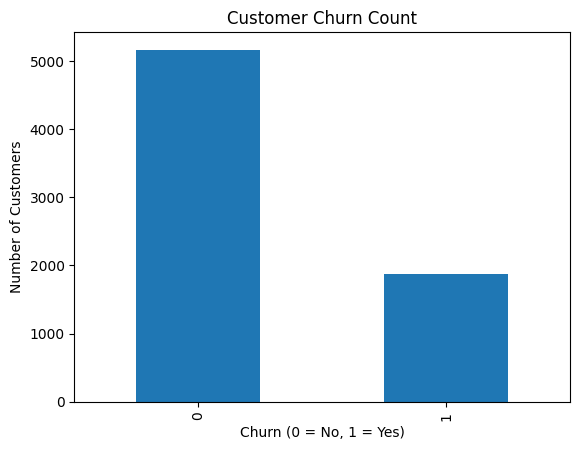

In [10]:
df['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Count')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')

plt.show()

In [11]:
plt.savefig('../images/churn_count.png')

<Figure size 640x480 with 0 Axes>

## First Insight

I analyzed the customer churn data and found that a portion of customers are leaving the service. Understanding why customers churn is important because it helps businesses improve retention and reduce revenue loss.

In [12]:
contract_churn = df.groupby('Contract')['Churn'].mean()

contract_churn

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn, dtype: float64

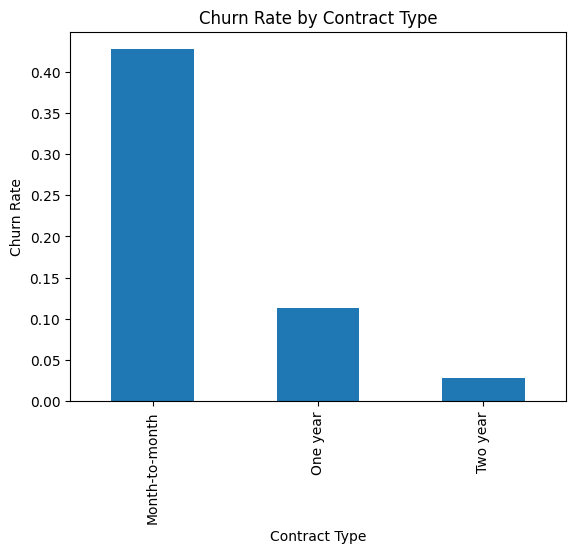

In [13]:
contract_churn.plot(kind='bar')

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate')

plt.show()

In [14]:
plt.savefig('../images/churn_by_contract.png')

<Figure size 640x480 with 0 Axes>

## Churn by Contract Type

I found that customers with month-to-month contracts have the highest churn rate. Customers with one-year and two-year contracts are much less likely to leave.

This suggests that longer-term contracts help improve customer retention. A business could reduce churn by encouraging customers to switch from month-to-month to longer-term plans through discounts or incentives.

<Figure size 640x480 with 0 Axes>

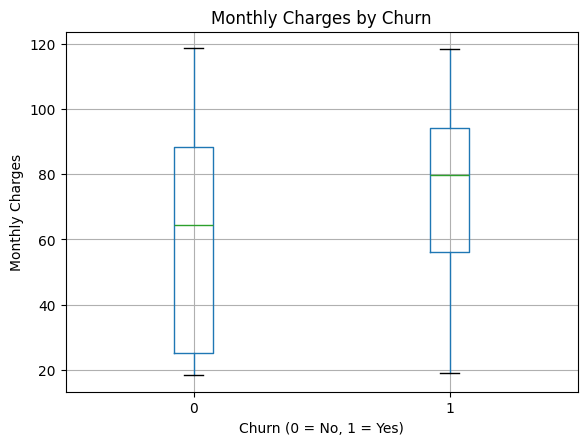

In [15]:
plt.figure()

df.boxplot(column='MonthlyCharges', by='Churn')

plt.title('Monthly Charges by Churn')
plt.suptitle('')  # removes extra title
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Monthly Charges')

plt.show()

In [16]:
plt.savefig('../images/churn_vs_monthly.png')

<Figure size 640x480 with 0 Axes>

## Churn vs Monthly Charges

The box plot shows that customers who churn tend to have higher monthly charges compared to those who stay.

This suggests that pricing may be a key factor in customer retention. Businesses could reduce churn by offering better pricing plans or incentives to higher-paying customers.

In [17]:
tenure_churn = df.groupby('Churn')['tenure'].mean()
tenure_churn

Churn
0    37.650010
1    17.979133
Name: tenure, dtype: float64

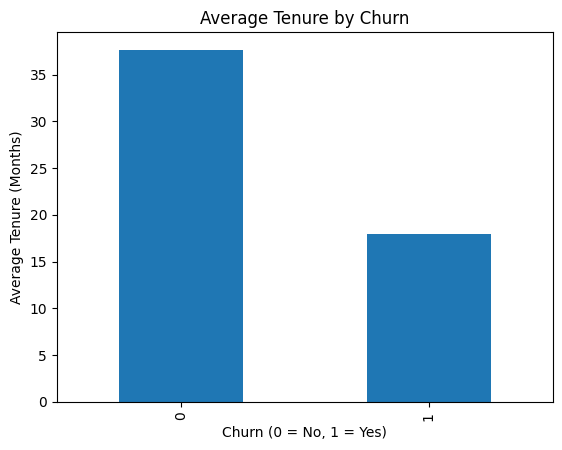

In [18]:
tenure_churn.plot(kind='bar')

plt.title('Average Tenure by Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Average Tenure (Months)')

plt.show()

In [19]:
plt.savefig('../images/churn_vs_tenure.png')

<Figure size 640x480 with 0 Axes>

## Churn vs Tenure

Customers who churn have a significantly lower average tenure compared to customers who stay.

This indicates that customers are more likely to leave early in their lifecycle. Businesses should focus on improving the onboarding experience and early engagement to increase retention.